In [25]:
# to run on collab, simply execute the following commands in a cell:
# !git clone https://github.com/Torpedoooo/deeplearning-assignment-1.git
# !pip install torch torchvision pandas seaborn scikit-learn
# !pip install nbconvert
# %cd deeplearning-assignment-1/
# !jupyter nbconvert --execute assignment1.ipynb \
#                     --to notebook --output executed.ipynb


In [26]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import seaborn as sns

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir,
                 transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)        
        classes = sorted(self.img_labels.iloc[:,1].unique())
        self.class2idx = {c:i for i,c in enumerate(classes)}
        self.img_dir    = img_dir
        self.transform  = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):         
            idx = idx.tolist()

        img_name = self.img_labels.iloc[idx, 0]            # first column = filename
        if not img_name.lower().endswith('.png'):
            img_name = img_name + '.png'
        label = self.img_labels.iloc[idx, 1]            # second column = class
        label = self.class2idx[label]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label

In [28]:
# build a transformation that will be applied to every image
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),    # make all samples the same size
    transforms.RandomHorizontalFlip(),# data‑augmentation
    transforms.ToTensor(),           
    transforms.Normalize(             # zero‑mean, unit‑variance per channel
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225])
])

In [29]:
df = pd.read_csv('train_labels.csv') 

# shuffle & take 80 % for training
train_df = df.sample(frac=0.8, random_state=42)

# the remainder 20%0  is the validation set
test_df  = df.drop(train_df.index)

train_df.to_csv('train_split.csv', index=False)
test_df.to_csv('test_split.csv',  index=False)

print("train:", len(train_df), "rows")
print("test :", len(test_df),  "rows")

train: 2880 rows
test : 720 rows


In [30]:

train_csv = './train_labels.csv'  
train_dir = './Train/'            

train_ds = CustomImageDataset('train_split.csv', train_dir, transform=train_transform)
test_ds  = CustomImageDataset('test_split.csv', train_dir, transform=val_transform)


# numeric labels for every train example
labels = train_ds.img_labels['label'].map(train_ds.class2idx)

#class‑level weights
class_counts  = labels.value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

# map the weight array
sample_weights = labels.map(class_weights).values
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

#sampler that will draw from the dataset with those probabilities
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(sample_weights),   # one draw per original example
    replacement = True                   # allow repeats to keep using less frequent labelks
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    sampler=sampler,     
   
)
print("split counts:\n", train_ds.img_labels['label'].value_counts())

for i in range(5):
    xb, yb = next(iter(train_loader))
    print("batch", i, torch.bincount(yb))
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

split counts:
 label
Water       550
Normal      488
Poison      369
Fire        306
Bug         294
Grass       240
Fighting    227
Rock        214
Ground      192
Name: count, dtype: int64
batch 0 tensor([5, 3, 4, 5, 6, 2, 4, 1, 2])
batch 1 tensor([5, 2, 3, 3, 4, 1, 5, 3, 6])
batch 2 tensor([4, 3, 3, 1, 2, 4, 5, 3, 7])
batch 3 tensor([4, 4, 5, 2, 3, 2, 4, 2, 6])
batch 4 tensor([3, 8, 4, 2, 4, 6, 1, 2, 2])


<Axes: title={'center': 'Label distribution'}, ylabel='label'>

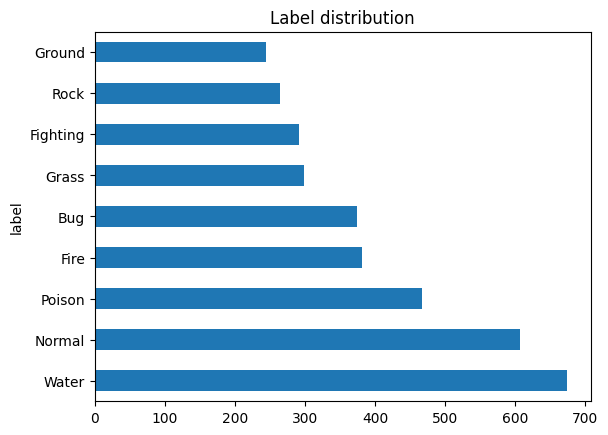

In [31]:
df = pd.read_csv('train_labels.csv')
counts = df['label'].value_counts()
counts.plot(kind='barh', title='Label distribution')


The dataset is unbalanced – the most common class (Water) has nearly three times as many examples as the least common (Ground).

The top three types (Water, Normal, Poison) alone comprise roughly 40 % of the samples.

There are only ~250–300 examples for the rarer types (Rock, Ground, Fighting, Grass).

A naive classifier trained with standard cross‑entropy loss will tend to favour the majority types, achieving deceptively high overall accuracy while performing poorly on the under‑represented classes.

To counteract this we calculate a weight for each class that is inversely proportional to its frequency:

In [32]:
criterion = nn.CrossEntropyLoss()

In [33]:
class MLP(nn.Module):
    def __init__(self, num_outputs, num_hiddens, lr=None):
        super().__init__()

        # num_hiddens can be a single int or a list of ints
        if isinstance(num_hiddens, int):
            num_hiddens = [num_hiddens]
       
        layers = [nn.Flatten()]                    # flatten from C×H×W to vector
        
        for h in num_hiddens:
            layers.append(nn.LazyLinear(h))        # size inferred on first forward
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))          # dropout for regularization
        
        layers.append(nn.LazyLinear(num_outputs))  # final classification layer
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)  

In [34]:
model = MLP(num_outputs=9, num_hiddens=[1024, 512, 256]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# helper to compute accuracy on a batch
def batch_accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

epochs = 50
for epoch in range(1, epochs+1):
    model.train()                        
    running_loss = 0.0
    running_acc  = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)               # forward pass
        loss = criterion(logits, yb)     # weighted cross‑entropy

        optimizer.zero_grad()
        loss.backward()                  # compute gradients
        optimizer.step()                 # update weights

        running_loss += loss.item() * xb.size(0)
        running_acc  += batch_accuracy(logits, yb) * xb.size(0)

    train_loss = running_loss / len(train_ds)
    train_acc  = running_acc  / len(train_ds)

    # validation
    model.eval()                      
    val_loss = 0.0
    val_acc  = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
            val_acc  += batch_accuracy(logits, yb) * xb.size(0)
    val_loss /= len(test_ds)
    val_acc  /= len(test_ds)

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}")

Epoch  1 | train loss 2.3987 acc 0.107 | val loss 2.2270 acc 0.113
Epoch  2 | train loss 2.2327 acc 0.121 | val loss 2.1985 acc 0.128
Epoch  3 | train loss 2.2183 acc 0.110 | val loss 2.1933 acc 0.138
Epoch  4 | train loss 2.1988 acc 0.133 | val loss 2.1788 acc 0.157
Epoch  5 | train loss 2.1737 acc 0.154 | val loss 2.1369 acc 0.175
Epoch  6 | train loss 2.1619 acc 0.152 | val loss 2.1293 acc 0.168
Epoch  7 | train loss 2.1322 acc 0.170 | val loss 2.1243 acc 0.215
Epoch  8 | train loss 2.1133 acc 0.175 | val loss 2.1134 acc 0.157
Epoch  9 | train loss 2.1286 acc 0.172 | val loss 2.0706 acc 0.186
Epoch 10 | train loss 2.1257 acc 0.166 | val loss 2.0947 acc 0.197
Epoch 11 | train loss 2.0895 acc 0.174 | val loss 2.1158 acc 0.188
Epoch 12 | train loss 2.0965 acc 0.181 | val loss 2.1212 acc 0.168
Epoch 13 | train loss 2.1124 acc 0.191 | val loss 2.1024 acc 0.161


KeyboardInterrupt: 

In [ ]:
# --- evaluation on validation set ------------------------------------------
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:     
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(yb.cpu())

all_preds   = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

# overall accuracy
accuracy = (all_preds == all_targets).float().mean().item()
print(f"validation accuracy: {accuracy:.4f}")

# per‑class metrics
type_names = sorted(train_ds.class2idx, key=lambda k: train_ds.class2idx[k])
print(classification_report(all_targets, all_preds,
                            target_names=type_names))

# confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=type_names,
            yticklabels=type_names, cmap="Blues")
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix")
plt.show()

In [ ]:
idx2class = {v:k for k,v in train_ds.class2idx.items()}
test_ids = [f.split('.png')[0] for f in os.listdir('Test') if f.endswith('.png')]

class ImageOnlyDataset(Dataset):
    def __init__(self, ids, img_dir, transform=None):
        self.ids = ids
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        path = os.path.join(self.img_dir, name + '.png')
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

test_ds = ImageOnlyDataset(test_ids, 'Test/', transform=val_transform)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# prediction loop adjusts 
preds = []
with torch.no_grad():
    for xb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(1).cpu().tolist())
print("test prediction distribution:", torch.bincount(torch.tensor(preds)))
assert len(preds) == len(test_ids)

# map back to strings and write submission file
out_df = pd.DataFrame({
    'Id': test_ids,
    'label': [idx2class[i] for i in preds]
})
out_df.to_csv('submission2.csv', index=False)
print('wrote', len(out_df), 'predictions to submission.csv')